In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import FEATURES_OUTFILE
from dmm.initialisation import get_features, pca_transform_features
from sklearn.decomposition import PCA, SparsePCA
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [35]:
def rmse(data: np.ndarray, pred: np.ndarray) -> float: 
    return np.sqrt(np.mean(np.square(data - pred)))

In [36]:
# Set up minimal conf
conf_dict = {
    "model": "EGFR_MAPK", 
    "data": "dream_cytof", 
    "samples": "0of5", 
    "features": "all", 
    "context": "cytof_dynamic", 
}

# Define filepath for features file
features_filepath = FEATURES_OUTFILE.format(
    **{**conf_dict, **dict(dataset = "{dataset}")}
)

# Define datasets and load features
settings = {
        "train": ["train"],
        "test": ["val"],
        "train+test": ["train", "val"],
}

features = get_features(features_filepath=features_filepath, datasets=settings["train+test"])

In [37]:
# First try fitting a PCA pipeline with as many components as possible
pipeline = Pipeline([
    ('scaler', StandardScaler(with_std=False)),
    # ("imputer", KNNImputer()),  # add to match regressor setup
    ('pca', PCA(
        n_components=None,  # keep all
        whiten=True, 
    ))  # added whitening
])

# fit on training features
pipeline.fit(features["train"])

# transform both train and val
transformed_features = {
    dataset: pd.DataFrame(
        pipeline.transform(features[dataset]),
        index=features[dataset].index,
        columns=[f'pca_{i}' for i in range(pipeline.named_steps['pca'].n_components_)]
    )
    for dataset in features.keys()
}

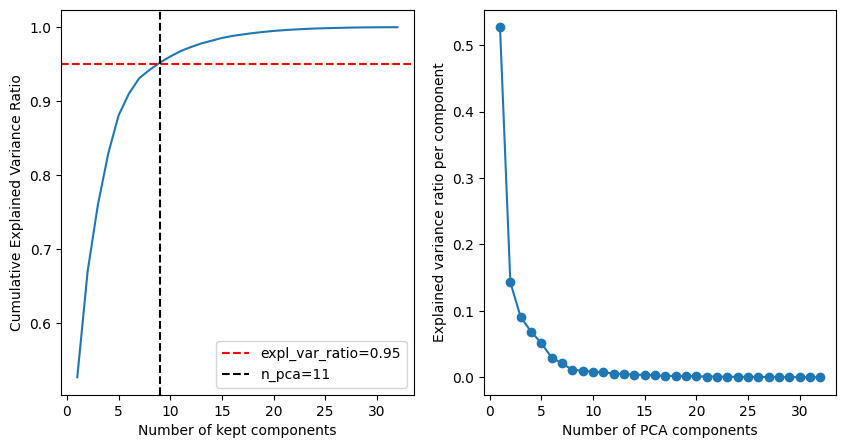

In [38]:
# Examine explained variance on standard training set (32 cell lines)
# PCA cannot return more principal components than number of rows = cell-lines = 32
# whereas original features["train"] matrix has 76 columns
cum_expl_var = pipeline.named_steps["pca"].explained_variance_ratio_.cumsum()
plt.subplots(1, 2, figsize=(10, 5))
plt.subplot(121)
plt.plot(np.arange(1, min(features["train"].shape)+1), cum_expl_var)
plt.axhline(0.95, color='red', ls='--', label="expl_var_ratio=0.95")
plt.axvline(9, color='black', ls='--', label="n_pca=11")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.xlabel("Number of kept components")
plt.legend()
plt.subplot(122)
plt.plot(np.arange(1, min(features["train"].shape)+1), pipeline.named_steps["pca"].explained_variance_ratio_, marker='o')
plt.ylabel("Explained variance ratio per component")
plt.xlabel("Number of PCA components")
plt.show()

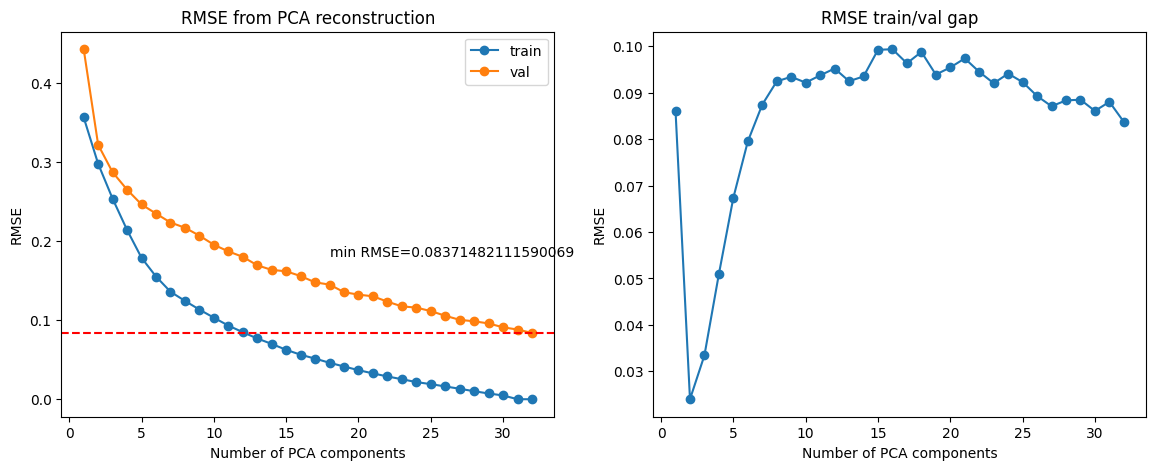

In [39]:
rmses = {"train": [], "val": []}
for k in range(min(features["train"].shape)): 
    pipeline = Pipeline([
        # ('scaler', StandardScaler(with_std=False, with_mean=False)),
        # ("imputer", KNNImputer()),  # add to match regressor setup
        ('pca', PCA(
            n_components=k+1,  # keep all
            whiten=True, 
        ))  # added whitening
    ])
    # fit on training features
    pipeline.fit(features["train"])
    
    # transform both train and val
    transformed_features = {
        dataset: pd.DataFrame(
            pipeline.transform(features[dataset]),
            index=features[dataset].index,
            columns=[f'pca_{i}' for i in range(pipeline.named_steps['pca'].n_components_)]
        )
        for dataset in features.keys()
    }
    
    # Compute RMSE w.r.t. original validation features and append
    for dataset in ["train", "val"]:
        rmses[dataset].append(
            rmse(
                features[dataset].values, 
                pipeline.inverse_transform(transformed_features[dataset])
            )
        )
plt.subplots(1, 2, figsize=(14, 5))
plt.subplot(1, 2, 1)
for dataset in ["train", "val"]:     
    plt.plot(np.arange(1, min(features["train"].shape)+1), rmses[dataset], marker='o', label=dataset)
plt.axhline(rmses["val"][-1], color='red', ls='--')
plt.text(18, 0.18, f"min RMSE={str(rmses['val'][-1])}", color='black')
plt.xlabel('Number of PCA components')
plt.ylabel('RMSE')
plt.legend()
plt.title("RMSE from PCA reconstruction");
plt.subplot(1, 2, 2)
plt.plot(np.arange(1, min(features["train"].shape)+1), np.array(rmses["val"])-np.array(rmses["train"]), marker='o', label='train')
plt.xlabel('Number of PCA components')
plt.ylabel('RMSE')
plt.title("RMSE train/val gap");
plt.savefig("cytof_dynamic_PCA_analysis.pdf")

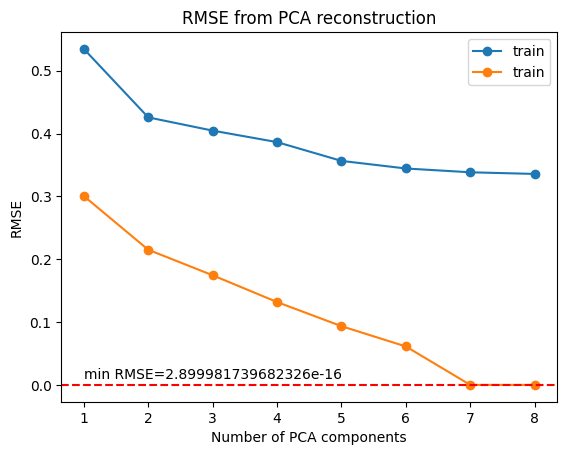

In [24]:
# What would happen if we fitted PCA on validation and evaluated on training? (much fewer examples in validation)
rmses = {"train": [], "val": []}
for k in range(min(features["val"].shape)): 
    pipeline = Pipeline([
        # ('scaler', StandardScaler(with_std=False)),
        # ("imputer", KNNImputer()),  # add to match regressor setup
        ('pca', PCA(
            n_components=k+1,  # keep all
            whiten=True, 
        ))  # added whitening
    ])
    # fit on training features
    pipeline.fit(features["val"])
    
    # transform both train and val
    transformed_features = {
        dataset: pd.DataFrame(
            pipeline.transform(features[dataset]),
            index=features[dataset].index,
            columns=[f'pca_{i}' for i in range(pipeline.named_steps['pca'].n_components_)]
        )
        for dataset in features.keys()
    }
    
    # Compute RMSE w.r.t. original validation features and append
    for dataset in ["train", "val"]:
        rmses[dataset].append(
            rmse(
                features[dataset].values, 
                pipeline.inverse_transform(transformed_features[dataset])
            )
        )
for dataset in ["train", "val"]:     
    plt.plot(np.arange(1, min(features["val"].shape)+1), rmses[dataset], marker='o', label='train')
plt.axhline(rmses["val"][-1], color='red', ls='--')
plt.text(1, 0.01, f"min RMSE={str(rmses['val'][-1])}", color='black')
plt.xlabel('Number of PCA components')
plt.ylabel('RMSE')
plt.legend()
plt.title("RMSE from PCA reconstruction");